In [ ]:
import os, sys
import json
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import itertools
import seaborn as sns
from scipy.stats import mannwhitneyu


from src.utils import *

In [2]:
results = './results/results.json'
with open(results, 'r') as f:
    results = json.load(f)
times = [], []
labels = []
for k, v in results.items():
    times[0].append(v['bmssp'])
    times[1].append(v['dijkstra'])
    labels.append(str(pd.to_datetime(k)).split(' ')[0])

data = read_zip('./data/prepared.json.zip')
data = json.load(data)
for k, v in data['graphs'].items():
    data['graphs'][k] = graph_from_dict(v)

In [5]:
info = []
for k, v in data['graphs'].items():
    g = data['graphs'][k]
    d = degrees(g)
    info.append({
        'Snapshot Date': str(pd.to_datetime(k)).split(' ')[0],
        'Nodes': len(g.nodes),
        'Channels': len(g.edges),
        'Avg. Degree ± Std. Dev.': f"{np.mean(d):.2f}±{np.std(d):.2f}",
        'Degree Entropy': f"{distribution_entropy(d)[1]:.2f}",
    })
info = pd.DataFrame(info)
info.to_csv('./results/info.csv', index=False)
info

,Snapshot Date,Nodes,Channels,Avg. Degree ± Std. Dev.,Degree Entropy
0,2019-06-17,4287,30652,14.30±52.23,0.60
1,2020-06-15,5697,28743,10.09±41.19,0.50
2,2021-06-15,10343,42746,8.27±42.47,0.44
3,2022-06-05,15648,78468,10.03±51.56,0.47
4,2023-07-16,15071,64196,8.52±46.44,0.43


(np.float64(249890.0), np.float64(1.1321759438777128e-164))

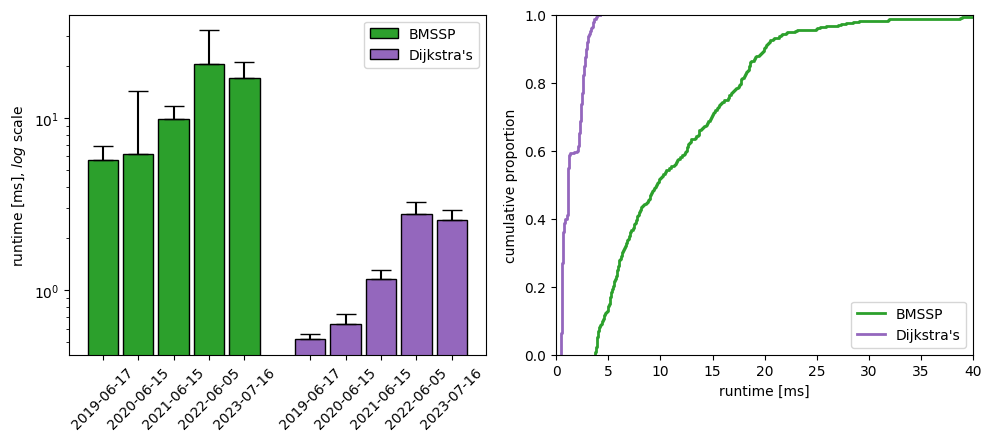

In [41]:
fig = plt.figure(figsize=(10., 4.5))
ax = fig.add_subplot(1, 2, 1)
x, barWidth = 0, 0.3
ticks = []
for i, t in enumerate(times[0] + times[1]):
    ticks.append(x)
    t, e = np.asarray(t).mean(), np.std(np.asarray(t))
    ax.bar(x, t, width=barWidth, yerr=[[0], [e]], capsize=7, edgecolor='black',
           color='tab:green' if i < len(times[0]) else 'tab:purple', label='1')
    x += barWidth + 0.05
    if i == len(times[0]) - 1:
        x += 0.3
h, l = ax.get_legend_handles_labels()
ax.legend(handles=[h[0], h[-1]], labels=['BMSSP', "Dijkstra's"], loc='upper right')
ax.set_xticks(ticks, labels * 2)
ax.tick_params(axis='x', labelrotation=45)
ax.set_yscale('log')
ax.set_ylabel('runtime [ms], $log$ scale')

ax = fig.add_subplot(1, 2, 2)
a = list(itertools.chain.from_iterable(times[0]))
ax.ecdf(a, label='BMSSP', color='tab:green', linewidth=2)
b = list(itertools.chain.from_iterable(times[1]))
ax.ecdf(b, label="Dijkstra's", color='tab:purple', linewidth=2)
ax.set_xlim(right=40, left=-0.05)
ax.set_xlabel('runtime [ms]')
ax.set_ylabel('cumulative proportion')
ax.legend(loc='lower right')

fig.tight_layout(pad=1.01)
fig.savefig('./results/fig01.pdf',
            dpi=600, bbox_inches='tight', format='pdf')

u, p = mannwhitneyu(a, b)
u, p

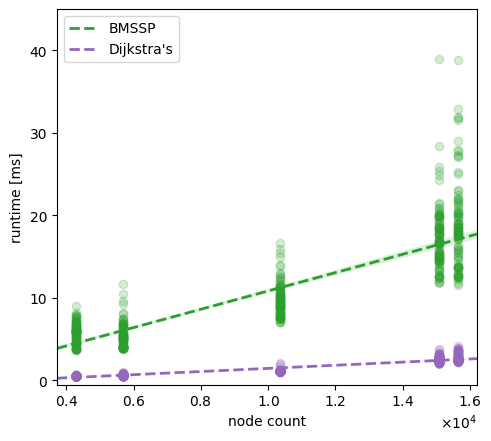

In [33]:
x, b, d = [], [], []
for k, v in data['graphs'].items():
    c = len(data['graphs'][k].nodes)
    x.append([c] * len(results[k]['bmssp']))
    b.append(results[k]['bmssp'])
    d.append(results[k]['dijkstra'])
x = list(itertools.chain.from_iterable(x))
b = list(itertools.chain.from_iterable(b))
d = list(itertools.chain.from_iterable(d))
fig = plt.figure(figsize=(5., 4.5))
ax = fig.add_subplot()
sns.regplot(x=x, y=b, color='tab:green', robust=True,
            truncate=False, ax=ax, 
            scatter_kws=dict(alpha=0.2),
            line_kws=dict(alpha=1, lw=2, ls='-.', label="BMSSP"))
sns.regplot(x=x, y=d, color='tab:purple', robust=True,
            truncate=False, ax=ax,  
            scatter_kws=dict(alpha=0.2),
            line_kws=dict(alpha=1, lw=2, ls='-.', label="Dijkstra's"))
ax.set_ylim(top=45, bottom=-0.5)
ax.lines[0].set_linestyle("--")
ax.lines[1].set_linestyle("--")
xfmt = ScalarFormatter(useMathText=True)
xfmt.set_powerlimits((0,0))
ax.xaxis.set_major_formatter(xfmt)
ax.set_ylabel('runtime [ms]')
ax.set_xlabel('node count')
ax.legend(loc='upper left')

fig.tight_layout(pad=1.01)
fig.savefig('./results/fig02.pdf',
            dpi=600, bbox_inches='tight', format='pdf')